# Novelty-Bonus Subgoal Selection

Restores the **horizon-conditioned** GC flow goal proposer (`observation_horizon_h1_100`) and implements six novelty-bonus strategies for selecting among candidate subgoals:

| Method | Idea |
|---|---|
| **Count-based** | `1 / sqrt(1 + N(s))` on a discrete grid |
| **RND** | MSE between a trained predictor and a fixed random target network |
| **RND + Fourier** | Same as RND but inputs are first mapped through random Fourier features |
| **Epsilon-greedy** | Uniform random exploration that decays toward count-based selection |
| **Ensemble disagreement** | Variance across K predictor networks sharing one fixed target |
| **SimHash** | Count-in-bucket with locality-sensitive hashing (works in any dimension) |

Each method is wrapped in a `SubgoalSelector` that samples N candidates from the proposer and picks the highest-scoring one.  An **oracle rollout** (no low-level controller) drives coverage experiments: the agent jumps directly to its chosen subgoal each step.

In [2]:
from __future__ import annotations

import os
os.environ.setdefault('JAX_PLATFORMS', 'cpu')

import jax
import jax.numpy as jnp
import flax.linen as nn
import optax
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
from tqdm.auto import trange

from agents.goal_proposer import make_goal_proposer_config, restore_gc_flow_goal_proposer

/home/jennifer/miniconda3/envs/aorl/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/jennifer/miniconda3/envs/aorl/lib/python3.10/site-packages/Cython/Distutils/old_build_ext.py:15: DeprecationWarning: dep_util is Deprecated. Use functions from setuptools instead.
  from distutils.dep_util import newer, newer_group
/home/jennifer/miniconda3/envs/aorl/lib/python3.10/site-packages/Cython/Distutils/old_build_ext.py:15: DeprecationWarning: dep_util is Deprecated. Use functions from setuptools instead.
  from distutils.dep_util import newer, newer_group
<frozen importlib._bootstrap>:283: DeprecationWarning: the load_module() method is deprecated and slated for removal in Python 3.12; use exec_module() instead


In [3]:
ENV_NAME = 'humanoidmaze-giant-navigate-v0'
ENV_DATASET_PATH = '../../scratch/data/humanoidmaze-giant-navigate-v0/humanoidmaze-giant-navigate-100m-v0/humanoidmaze-giant-navigate-v0-003.npz'

base_config = dict(
    observations_key='observations',
    goal_key='actor_goals',
    hidden_dims=(256, 256, 256),
    layer_norm=True,
    lr=3e-4,
    flow_steps=10,
    seed=0,
    discount=0.995,
    backup_horizon=25,
)

config = make_goal_proposer_config(
    'observation_horizon_h1_100',
    observation_conditioned=True,
    horizon_conditioned=True,
    base_config=base_config,
)

example_batch = dict(
    observations=np.zeros((1, 2), dtype=np.float32),
    actor_goals=np.zeros((1, 2), dtype=np.float32),
    low_actor_goals=np.zeros((1, 2), dtype=np.float32),
    horizons=np.full((1, 1), 100.0, dtype=np.float32),
)

proposer, checkpoint_step = restore_gc_flow_goal_proposer(
    'observation_horizon_h1_100', example_batch, config
)
print(f'Restored proposer from checkpoint {checkpoint_step:,}')

with np.load(ENV_DATASET_PATH) as ds:
    env_xy = ds['observations'][:, :2]
all_cell_points = np.unique(np.floor(env_xy), axis=0).astype(np.float32)
print(f'Maze cells: {len(all_cell_points):,}')

Restored from checkpoints/gc_flow_goal_proposer/observation_horizon_h1_100/params_5000000.pkl
Restored proposer from checkpoint 5,000,000
Maze cells: 1,376


## Novelty Scorers

All scorers share the same two-method interface:

```python
scorer.score(candidates: np.ndarray) -> np.ndarray   # (N,) novelty score per candidate
scorer.update(visited: np.ndarray)                    # update internal state after visiting
```

### 1 · Count-Based

In [4]:
class CountBasedNovelty:
    """Visit-count bonus: 1 / sqrt(1 + N(s)) on a regular grid."""

    def __init__(self, bin_size: float = 1.0):
        self.bin_size = bin_size
        self._counts: dict[tuple, int] = defaultdict(int)

    def _key(self, xy: np.ndarray) -> tuple:
        return tuple(np.floor(np.asarray(xy[:2]) / self.bin_size).astype(int).tolist())

    def score(self, candidates: np.ndarray) -> np.ndarray:
        return np.array([1.0 / np.sqrt(1.0 + self._counts[self._key(c)]) for c in candidates])

    def update(self, visited: np.ndarray) -> None:
        self._counts[self._key(visited)] += 1

    @property
    def num_unique_cells(self) -> int:
        return sum(1 for v in self._counts.values() if v > 0)

### 2 · RND (Random Network Distillation)

In [5]:
class _RNDNet(nn.Module):
    """Small MLP used as RND target/predictor."""
    hidden_dims: tuple
    embed_dim: int

    @nn.compact
    def __call__(self, x: jax.Array) -> jax.Array:
        for d in self.hidden_dims:
            x = nn.Dense(d)(x)
            x = nn.relu(x)
        return nn.Dense(self.embed_dim)(x)


class RNDNovelty:
    """Random Network Distillation novelty bonus.

    novelty(s) = || predictor(s) - target(s) ||^2

    The target is a fixed random network.  The predictor is updated
    online with one gradient step each time a subgoal is visited.
    """

    def __init__(
        self,
        obs_dim: int,
        embed_dim: int = 64,
        hidden_dims: tuple = (128, 128),
        lr: float = 3e-4,
        seed: int = 0,
    ):
        rng = jax.random.PRNGKey(seed)
        rng, k_target, k_pred = jax.random.split(rng, 3)
        dummy = jnp.zeros((1, obs_dim))

        self._net = _RNDNet(hidden_dims=hidden_dims, embed_dim=embed_dim)
        self._target_params = self._net.init(k_target, dummy)
        self._pred_params   = self._net.init(k_pred,   dummy)
        self._opt           = optax.adam(lr)
        self._opt_state     = self._opt.init(self._pred_params)

    # ------------------------------------------------------------------ #

    def _error(self, pred_params, x: jax.Array) -> jax.Array:
        """Per-sample MSE between predictor and target output."""
        pred   = self._net.apply(pred_params,        x)
        target = self._net.apply(self._target_params, x)
        return jnp.mean((pred - target) ** 2, axis=-1)

    def score(self, candidates: np.ndarray) -> np.ndarray:
        x = jnp.asarray(candidates, dtype=jnp.float32)
        if x.ndim == 1:
            x = x[None]
        return np.asarray(self._error(self._pred_params, x))

    def update(self, visited: np.ndarray) -> float:
        x = jnp.asarray(np.asarray(visited, dtype=np.float32).reshape(1, -1))
        loss, grads = jax.value_and_grad(
            lambda p: jnp.mean(self._error(p, x))
        )(self._pred_params)
        updates, self._opt_state = self._opt.update(grads, self._opt_state)
        self._pred_params = optax.apply_updates(self._pred_params, updates)
        return float(loss)

### 3 · RND + Random Fourier Features

Random Fourier features approximate an RBF kernel:  
`phi(x) = sqrt(2/D) * cos(W x + b)`,  W ~ N(0, σ² I),  b ~ U[0, 2π].

Pre-projecting the input gives the RND networks a richer spectral basis, helping detect novelty at multiple spatial frequencies.

In [6]:
class RNDFourierNovelty(RNDNovelty):
    """RND where inputs are first projected through random Fourier features."""

    def __init__(
        self,
        obs_dim: int,
        num_fourier: int = 64,
        sigma: float = 0.5,
        embed_dim: int = 64,
        hidden_dims: tuple = (128, 128),
        lr: float = 3e-4,
        seed: int = 0,
    ):
        rng = np.random.RandomState(seed)
        self._W     = (rng.randn(obs_dim, num_fourier) * sigma).astype(np.float32)
        self._b     = rng.uniform(0.0, 2.0 * np.pi, num_fourier).astype(np.float32)
        self._scale = np.float32(np.sqrt(2.0 / num_fourier))
        super().__init__(num_fourier, embed_dim, hidden_dims, lr, seed)

    def _fourier(self, x: np.ndarray) -> np.ndarray:
        x = np.asarray(x, dtype=np.float32)
        if x.ndim == 1:
            return np.cos(x @ self._W + self._b) * self._scale
        return np.cos(x @ self._W + self._b) * self._scale

    def score(self, candidates: np.ndarray) -> np.ndarray:
        return super().score(self._fourier(candidates))

    def update(self, visited: np.ndarray) -> float:
        return super().update(self._fourier(visited))

### 4 · Epsilon-Greedy

In [7]:
class EpsilonGreedyNovelty:
    """Epsilon-greedy exploration over candidate subgoals.

    With probability *epsilon* the scorer returns uniform random scores
    (pure exploration).  With probability 1 - epsilon it delegates to
    *base_scorer*.  Epsilon decays linearly from *epsilon_start* to
    *epsilon_end* over *decay_steps* update calls.
    """

    def __init__(
        self,
        base_scorer,
        epsilon_start: float = 1.0,
        epsilon_end: float = 0.05,
        decay_steps: int = 200,
        seed: int = 0,
    ):
        self._scorer   = base_scorer
        self._eps      = float(epsilon_start)
        self._eps_end  = float(epsilon_end)
        self._decay    = (epsilon_start - epsilon_end) / max(decay_steps, 1)
        self._rng      = np.random.RandomState(seed)

    @property
    def epsilon(self) -> float:
        return self._eps

    def score(self, candidates: np.ndarray) -> np.ndarray:
        if self._rng.rand() < self._eps:
            return self._rng.rand(len(candidates))  # uniform → random pick
        return self._scorer.score(candidates)

    def update(self, visited: np.ndarray) -> None:
        self._scorer.update(visited)
        self._eps = max(self._eps_end, self._eps - self._decay)

### 5 · Ensemble Disagreement

Trains K predictor networks against one shared fixed target.  
`novelty(s) = Var_i [ predictor_i(s) ]` — high variance means the ensemble has not converged on this input.

In [8]:
class EnsembleDisagreementNovelty:
    """Novelty via predictor-ensemble disagreement (K predictors, 1 target)."""

    def __init__(
        self,
        obs_dim: int,
        num_ensemble: int = 5,
        embed_dim: int = 64,
        hidden_dims: tuple = (128, 128),
        lr: float = 3e-4,
        seed: int = 0,
    ):
        # Create K independent predictors; share the first one's target
        self._members = [
            RNDNovelty(obs_dim, embed_dim, hidden_dims, lr, seed=seed + i)
            for i in range(num_ensemble)
        ]
        shared_target = self._members[0]._target_params
        for m in self._members:
            m._target_params = shared_target

    def score(self, candidates: np.ndarray) -> np.ndarray:
        x = jnp.asarray(candidates, dtype=jnp.float32)
        if x.ndim == 1:
            x = x[None]
        # (K, N, embed_dim) → variance over K → mean over embed_dim
        all_preds = jnp.stack([
            self._members[0]._net.apply(m._pred_params, x)
            for m in self._members
        ])  # (K, N, embed_dim)
        return np.asarray(jnp.mean(jnp.var(all_preds, axis=0), axis=-1))  # (N,)

    def update(self, visited: np.ndarray) -> None:
        for m in self._members:
            m.update(visited)

### 6 · SimHash Count-Based

Projects inputs with a random binary hash `h(x) = sign(A x)`, A ~ N(0, I).  
States that collide in the hash bucket share a count.  Works in any dimension without axis-aligned binning.

In [9]:
class SimHashNovelty:
    """SimHash count-based novelty: bonus = 1 / sqrt(1 + N(bucket(s)))."""

    def __init__(self, obs_dim: int, num_bits: int = 16, seed: int = 0):
        rng = np.random.RandomState(seed)
        self._A      = rng.randn(num_bits, obs_dim).astype(np.float32)
        self._counts: dict[tuple, int] = defaultdict(int)

    def _key(self, x: np.ndarray) -> tuple:
        bits = (np.asarray(x, dtype=np.float32) @ self._A.T >= 0).astype(np.uint8)
        return tuple(bits.tolist())

    def score(self, candidates: np.ndarray) -> np.ndarray:
        return np.array([1.0 / np.sqrt(1.0 + self._counts[self._key(c)]) for c in candidates])

    def update(self, visited: np.ndarray) -> None:
        self._counts[self._key(np.asarray(visited))] += 1

## Subgoal Selector

Wraps any scorer with the proposer.  Each call samples `num_candidates` subgoals, ranks them, and returns the top one.

In [10]:
class SubgoalSelector:
    """Samples candidates from the proposer, scores them, picks the best.

    The proposer's `sample_actions` API requires observation_conditioned
    proposers to receive a full batch of repeated observations, so we
    tile the current obs manually.
    """

    def __init__(
        self,
        proposer,
        novelty_scorer,
        num_candidates: int = 128,
        horizon: float | None = None,
        seed: int = 0,
    ):
        self.proposer       = proposer
        self.scorer         = novelty_scorer
        self.num_candidates = int(num_candidates)
        self.horizon        = float(horizon or proposer.config['subgoal_steps'])
        self._rng           = jax.random.PRNGKey(seed)

    def select(
        self, obs: np.ndarray
    ) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
        """Return (best_subgoal, all_candidates, all_scores)."""
        self._rng, sample_rng = jax.random.split(self._rng)
        obs1d = np.asarray(obs, dtype=np.float32)
        obs_batch = np.repeat(obs1d[None] if obs1d.ndim == 1 else obs1d, self.num_candidates, axis=0)

        candidates = np.asarray(
            self.proposer.sample_actions(
                observations=obs_batch,
                horizons=self.horizon,
                rng=sample_rng,
            ),
            dtype=np.float32,
        )

        scores   = self.scorer.score(candidates)          # (N,)
        best_idx = int(np.argmax(scores))
        best     = candidates[best_idx].copy()
        self.scorer.update(best)
        return best, candidates, scores

## Oracle Rollout & Visualization

The oracle rollout jumps directly to each chosen subgoal — no low-level controller, no physics.  This isolates the proposer + novelty scorer behavior and measures state-space coverage.

In [11]:
def oracle_rollout(
    selector: SubgoalSelector,
    start_obs: np.ndarray,
    num_steps: int,
) -> dict:
    """Pure oracle subgoal chain driven by the novelty scorer.

    Returns:
        trajectory:  (num_steps+1, obs_dim)
        candidates:  list of (num_candidates, obs_dim) per step
        scores:      list of (num_candidates,) per step
    """
    obs        = np.asarray(start_obs, dtype=np.float32)
    trajectory = [obs.copy()]
    all_cands  = []
    all_scores = []

    for _ in trange(num_steps, leave=False):
        best, cands, scores = selector.select(obs)
        trajectory.append(best)
        all_cands.append(cands)
        all_scores.append(scores)
        obs = best

    return {
        'trajectory': np.stack(trajectory),
        'candidates': all_cands,
        'scores':     all_scores,
    }

In [12]:
def plot_coverage_maps(
    results: dict,
    all_cell_points: np.ndarray,
    start_obs: np.ndarray,
    ncols: int = 3,
    suptitle: str = '',
):
    """Side-by-side xy coverage maps, one panel per method."""
    names  = list(results.keys())
    n      = len(names)
    nrows  = (n + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 5 * nrows), squeeze=False)
    flat = axes.flatten()

    for ax, name in zip(flat, names):
        traj   = results[name]['trajectory']
        steps  = np.arange(len(traj))
        ax.scatter(all_cell_points[:, 0], all_cell_points[:, 1],
                   s=6, c='0.88', linewidths=0, zorder=1)
        sc = ax.scatter(traj[:, 0], traj[:, 1],
                        c=steps, cmap='plasma', s=14, zorder=3)
        ax.scatter(*start_obs[:2], marker='x', s=150, c='red', zorder=5)
        ax.set_title(name, fontsize=11)
        ax.set_aspect('equal')
        ax.set_xlabel('x')
        ax.set_ylabel('y')
        plt.colorbar(sc, ax=ax, label='step')

    for ax in flat[n:]:
        ax.set_visible(False)

    if suptitle:
        fig.suptitle(suptitle, fontsize=13, y=1.01)
    fig.tight_layout()
    return fig


def plot_unique_cells_over_time(results: dict, bin_size: float = 1.0):
    """Unique discrete cells visited vs. subgoal step count."""
    fig, ax = plt.subplots(figsize=(8, 4))
    for name, data in results.items():
        cells, counts = set(), []
        for obs in data['trajectory']:
            key = tuple(np.floor(obs[:2] / bin_size).astype(int).tolist())
            cells.add(key)
            counts.append(len(cells))
        ax.plot(counts, label=name)
    ax.set_xlabel('subgoal steps')
    ax.set_ylabel('unique cells visited')
    ax.set_title('Exploration Coverage over Time')
    ax.legend(loc='upper left', fontsize=9)
    fig.tight_layout()
    return fig


def plot_max_novelty_scores(results: dict):
    """Max novelty score among candidates at each step."""
    fig, ax = plt.subplots(figsize=(8, 4))
    for name, data in results.items():
        if data['scores']:
            maxs = [float(np.max(s)) for s in data['scores']]
            ax.plot(maxs, label=name, alpha=0.85)
    ax.set_xlabel('subgoal step')
    ax.set_ylabel('max novelty score (winning candidate)')
    ax.set_title('Max Novelty Score over Time')
    ax.legend(loc='upper right', fontsize=9)
    fig.tight_layout()
    return fig


def plot_candidate_clouds(results: dict, step: int, all_cell_points: np.ndarray):
    """At a given step, show the full candidate cloud coloured by novelty score."""
    names = list(results.keys())
    n     = len(names)
    ncols = min(3, n)
    nrows = (n + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 5 * nrows), squeeze=False)
    flat = axes.flatten()

    for ax, name in zip(flat, names):
        data   = results[name]
        if step >= len(data['candidates']):
            ax.set_title(f'{name}\n(step {step} unavailable)')
            continue
        cands  = data['candidates'][step]
        scores = data['scores'][step]
        traj   = data['trajectory']
        obs    = traj[step]

        ax.scatter(all_cell_points[:, 0], all_cell_points[:, 1],
                   s=5, c='0.90', linewidths=0, zorder=1)
        sc = ax.scatter(cands[:, 0], cands[:, 1],
                        c=scores, cmap='YlOrRd', s=20, zorder=3,
                        vmin=scores.min(), vmax=scores.max())
        best_idx = int(np.argmax(scores))
        ax.scatter(*cands[best_idx, :2], marker='*', s=200, c='green',
                   zorder=6, label='selected')
        ax.scatter(*obs[:2], marker='x', s=150, c='red', zorder=5, label='current obs')
        ax.set_title(name, fontsize=10)
        ax.set_aspect('equal')
        ax.set_xlabel('x')
        ax.set_ylabel('y')
        plt.colorbar(sc, ax=ax, label='novelty')
        ax.legend(fontsize=8)

    for ax in flat[n:]:
        ax.set_visible(False)

    fig.suptitle(f'Candidate clouds at step {step}', fontsize=12)
    fig.tight_layout()
    return fig

## Run All Experiments

In [13]:
START_OBS      = np.array([0.0, 0.0], dtype=np.float32)
HORIZON        = 100.0   # horizon passed to the proposer at each step
NUM_CANDIDATES = 128     # subgoals sampled per step
NUM_STEPS      = 300     # oracle rollout length
SEED           = 0
OBS_DIM        = 2       # xy position

In [14]:
def make_selectors(seed: int = 0) -> dict:
    """Instantiate one SubgoalSelector per novelty method."""
    methods = {
        'count-based': CountBasedNovelty(bin_size=1.0),
        'rnd': RNDNovelty(
            OBS_DIM, embed_dim=64, hidden_dims=(128, 128), seed=seed
        ),
        'rnd-fourier': RNDFourierNovelty(
            OBS_DIM, num_fourier=64, sigma=0.5, embed_dim=64,
            hidden_dims=(128, 128), seed=seed,
        ),
        'epsilon-greedy': EpsilonGreedyNovelty(
            CountBasedNovelty(bin_size=1.0),
            epsilon_start=1.0,
            epsilon_end=0.05,
            decay_steps=NUM_STEPS // 2,
            seed=seed,
        ),
        'ensemble-disagree': EnsembleDisagreementNovelty(
            OBS_DIM, num_ensemble=5, embed_dim=32,
            hidden_dims=(64, 64), seed=seed,
        ),
        'simhash': SimHashNovelty(OBS_DIM, num_bits=16, seed=seed),
    }
    return {
        name: SubgoalSelector(
            proposer, scorer,
            num_candidates=NUM_CANDIDATES,
            horizon=HORIZON,
            seed=seed,
        )
        for name, scorer in methods.items()
    }


selectors = make_selectors(SEED)
results   = {}

for name, sel in selectors.items():
    print(f'Rolling out {name} ...')
    results[name] = oracle_rollout(sel, START_OBS, NUM_STEPS)
    traj  = results[name]['trajectory']
    cells = {tuple(np.floor(p[:2]).astype(int).tolist()) for p in traj}
    print(f'  → {len(cells)} unique cells ({len(cells)/len(all_cell_points)*100:.1f}% of maze)')

Rolling out count-based ...


  → 301 unique cells (21.9% of maze)
Rolling out rnd ...


  → 147 unique cells (10.7% of maze)
Rolling out rnd-fourier ...


  → 149 unique cells (10.8% of maze)
Rolling out epsilon-greedy ...


  → 277 unique cells (20.1% of maze)
Rolling out ensemble-disagree ...


  → 115 unique cells (8.4% of maze)
Rolling out simhash ...


  → 79 unique cells (5.7% of maze)


## Visualizations

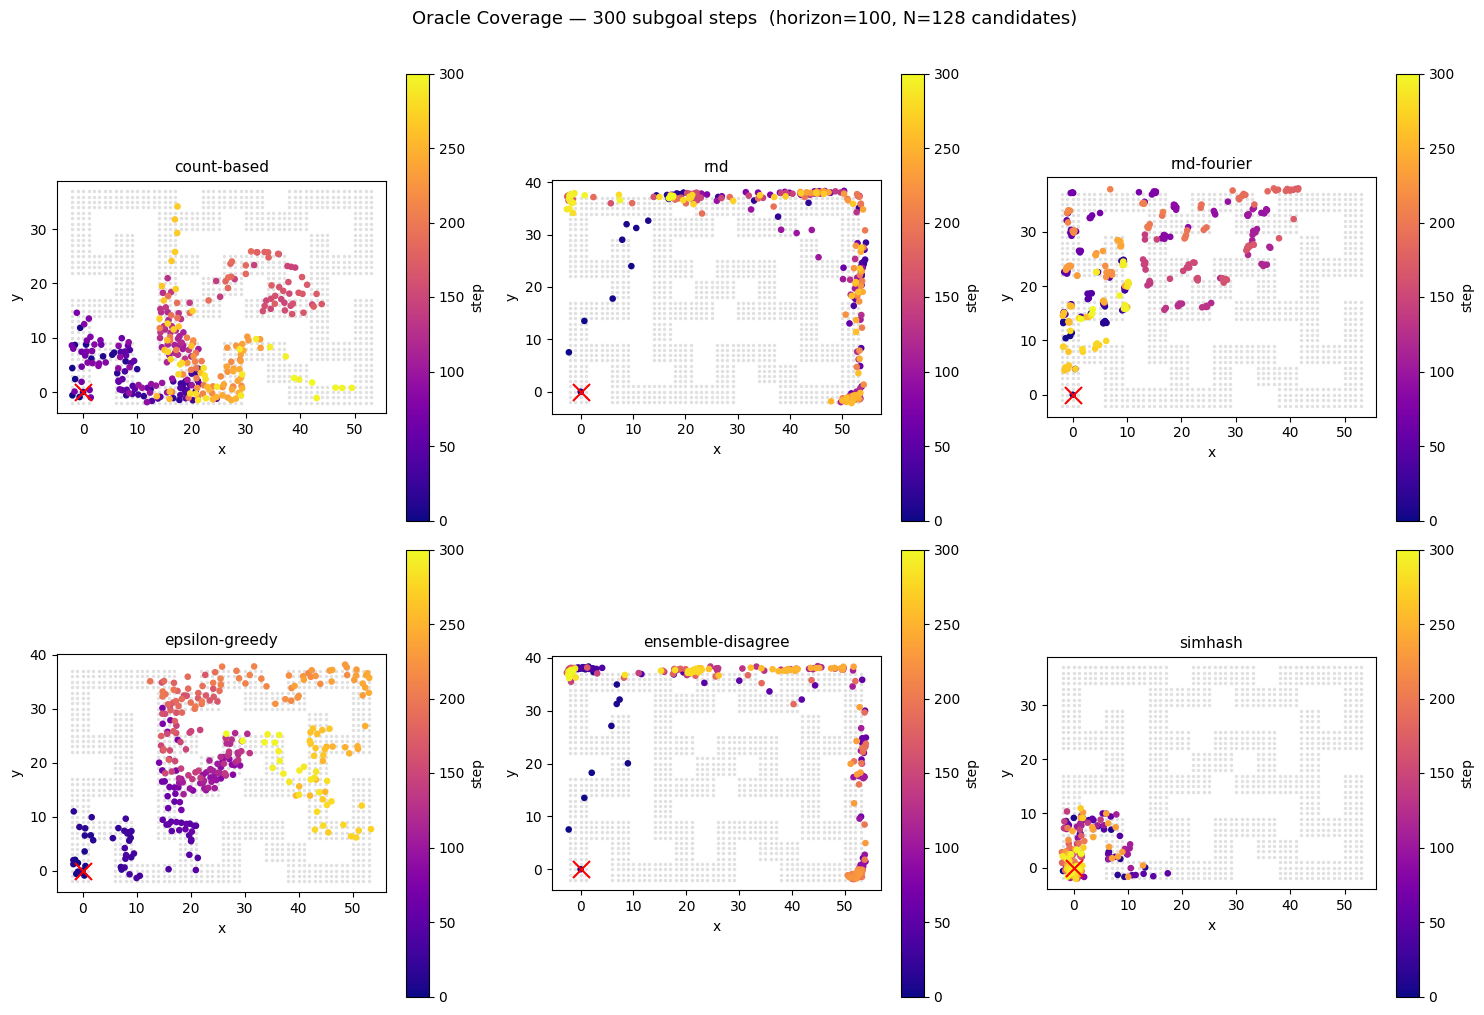

In [15]:
fig = plot_coverage_maps(
    results, all_cell_points, START_OBS,
    ncols=3,
    suptitle=f'Oracle Coverage — {NUM_STEPS} subgoal steps  (horizon={HORIZON:.0f}, N={NUM_CANDIDATES} candidates)',
)
plt.show()

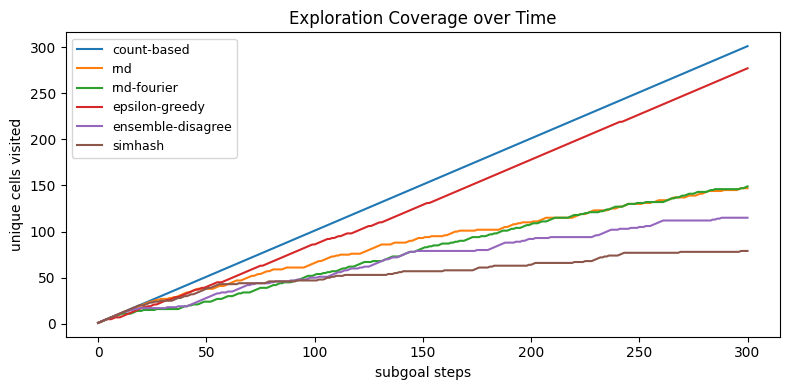

In [16]:
fig = plot_unique_cells_over_time(results, bin_size=1.0)
plt.show()

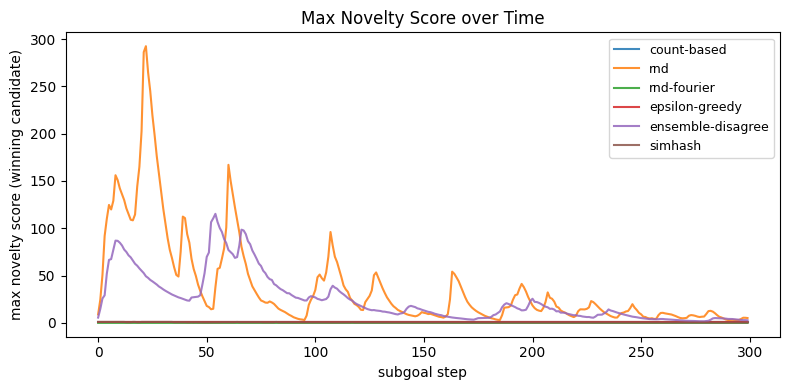

In [17]:
fig = plot_max_novelty_scores(results)
plt.show()

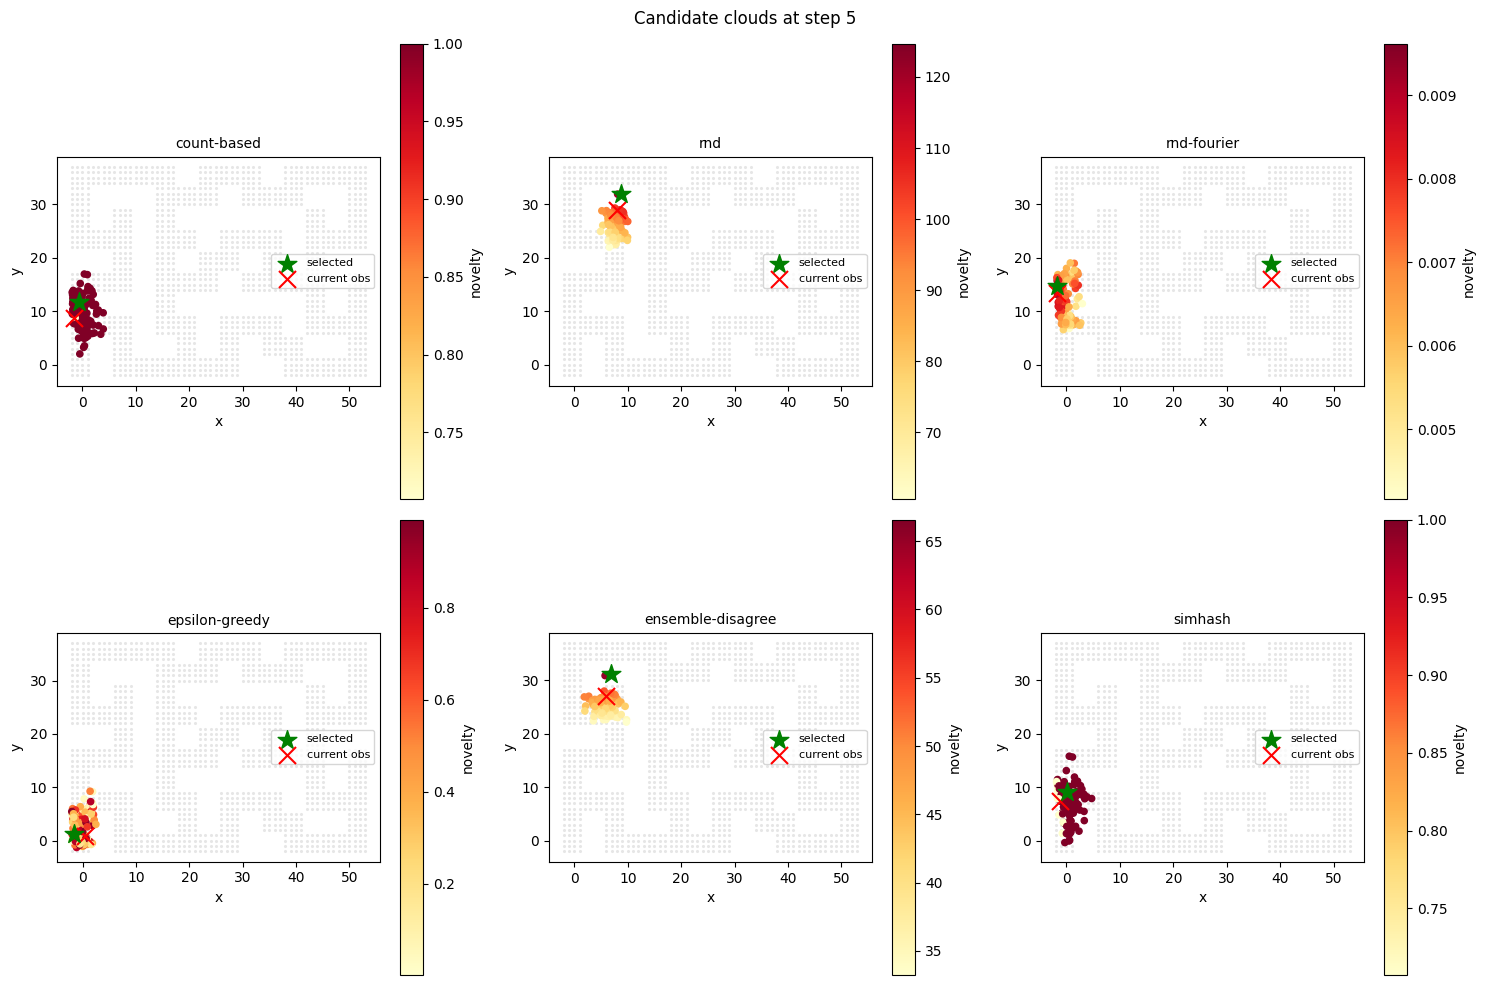

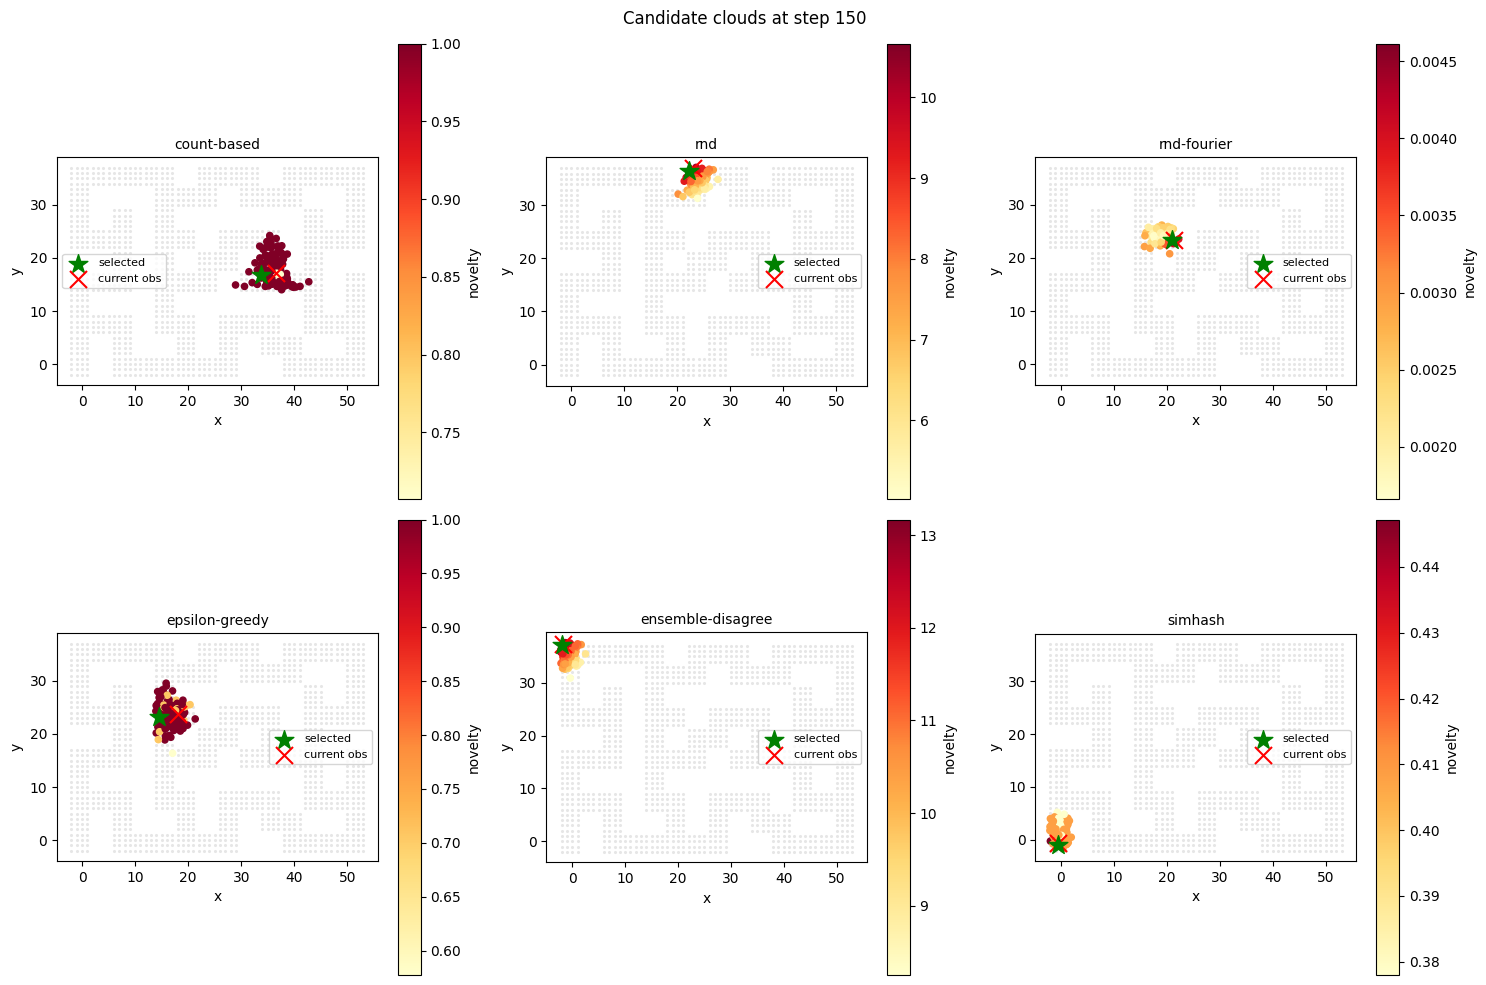

In [18]:
# Visualise the full candidate cloud + chosen subgoal at an early and a late step
for step in [5, NUM_STEPS // 2]:
    fig = plot_candidate_clouds(results, step=step, all_cell_points=all_cell_points)
    plt.show()

### Coverage Summary

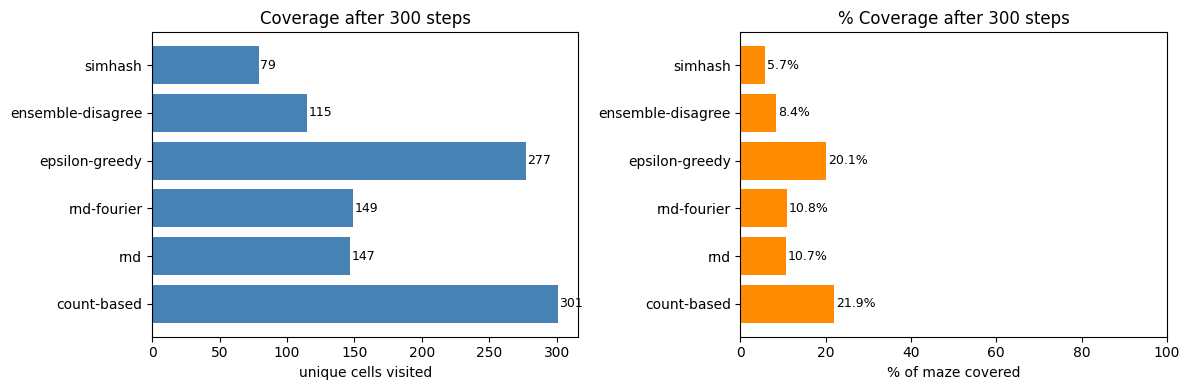

In [19]:
names         = list(results.keys())
cell_counts   = []
coverage_pcts = []

for name in names:
    traj  = results[name]['trajectory']
    cells = {tuple(np.floor(p[:2]).astype(int).tolist()) for p in traj}
    cell_counts.append(len(cells))
    coverage_pcts.append(len(cells) / len(all_cell_points) * 100)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].barh(names, cell_counts, color='steelblue')
axes[0].set_xlabel('unique cells visited')
axes[0].set_title(f'Coverage after {NUM_STEPS} steps')
for i, v in enumerate(cell_counts):
    axes[0].text(v + 1, i, str(v), va='center', fontsize=9)

axes[1].barh(names, coverage_pcts, color='darkorange')
axes[1].set_xlabel('% of maze covered')
axes[1].set_title(f'% Coverage after {NUM_STEPS} steps')
axes[1].set_xlim(0, 100)
for i, v in enumerate(coverage_pcts):
    axes[1].text(v + 0.5, i, f'{v:.1f}%', va='center', fontsize=9)

fig.tight_layout()
plt.show()

## Horizon Sensitivity

How does the proposer horizon affect coverage?  We sweep over a range of horizons with the best-performing method.

Rolling out horizon=10 ...


Rolling out horizon=25 ...


Rolling out horizon=50 ...


Rolling out horizon=100 ...


Rolling out horizon=200 ...


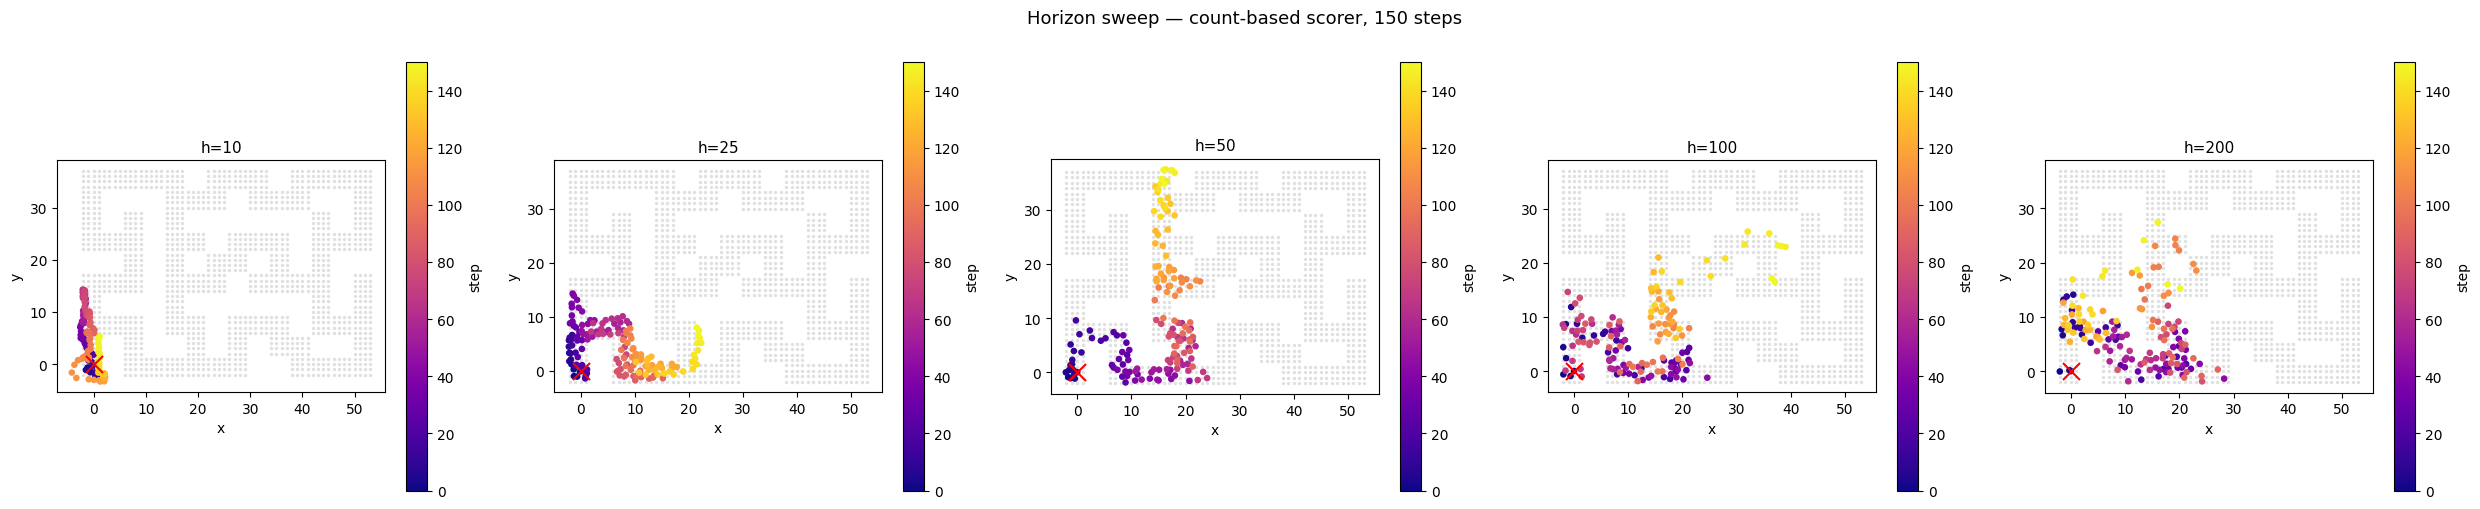

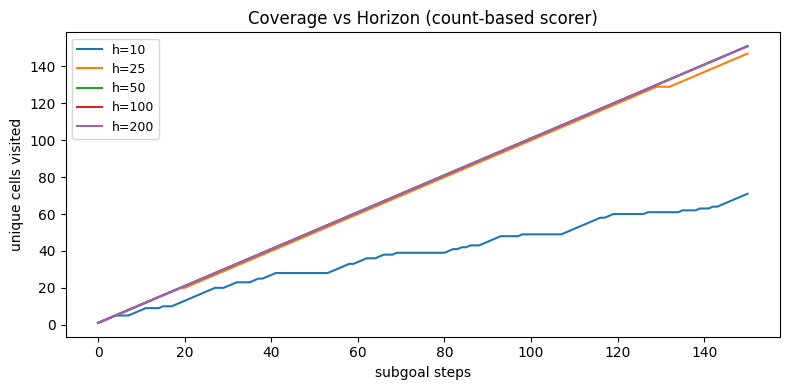

In [20]:
HORIZONS    = [10, 25, 50, 100, 200]
SWEEP_STEPS = 150
SWEEP_METHOD = 'count-based'  # use count-based as the stable baseline

horizon_results = {}
for h in HORIZONS:
    scorer = CountBasedNovelty(bin_size=1.0)
    sel    = SubgoalSelector(proposer, scorer, NUM_CANDIDATES, horizon=float(h), seed=SEED)
    key    = f'h={h}'
    print(f'Rolling out horizon={h} ...')
    horizon_results[key] = oracle_rollout(sel, START_OBS, SWEEP_STEPS)

fig = plot_coverage_maps(
    horizon_results, all_cell_points, START_OBS,
    ncols=len(HORIZONS),
    suptitle=f'Horizon sweep — count-based scorer, {SWEEP_STEPS} steps',
)
plt.show()

fig2 = plot_unique_cells_over_time(horizon_results)
fig2.axes[0].set_title('Coverage vs Horizon (count-based scorer)')
plt.show()

## Multi-Start Coverage

Run each method from several different start positions and measure aggregate maze coverage.

In [21]:
START_POSITIONS = [
    np.array([0.0,  0.0],  dtype=np.float32),
    np.array([30.0, 0.0],  dtype=np.float32),
    np.array([0.0,  30.0], dtype=np.float32),
    np.array([30.0, 30.0], dtype=np.float32),
]
MS_STEPS = 150  # steps per start

ms_results: dict[str, dict] = {name: {'trajectory': [], 'candidates': [], 'scores': []} for name in selectors}

for start in START_POSITIONS:
    sels = make_selectors(SEED)
    for name, sel in sels.items():
        res = oracle_rollout(sel, start, MS_STEPS)
        ms_results[name]['trajectory'].append(res['trajectory'])
        ms_results[name]['candidates'].extend(res['candidates'])
        ms_results[name]['scores'].extend(res['scores'])

# Concatenate trajectories across starts
for name in ms_results:
    ms_results[name]['trajectory'] = np.concatenate(ms_results[name]['trajectory'], axis=0)

print('Multi-start coverage:')
for name in ms_results:
    traj  = ms_results[name]['trajectory']
    cells = {tuple(np.floor(p[:2]).astype(int).tolist()) for p in traj}
    pct   = len(cells) / len(all_cell_points) * 100
    print(f'  {name}: {len(cells)} cells  ({pct:.1f}%)')

Multi-start coverage:
  count-based: 494 cells  (35.9%)
  rnd: 221 cells  (16.1%)
  rnd-fourier: 235 cells  (17.1%)
  epsilon-greedy: 432 cells  (31.4%)
  ensemble-disagree: 171 cells  (12.4%)
  simhash: 193 cells  (14.0%)


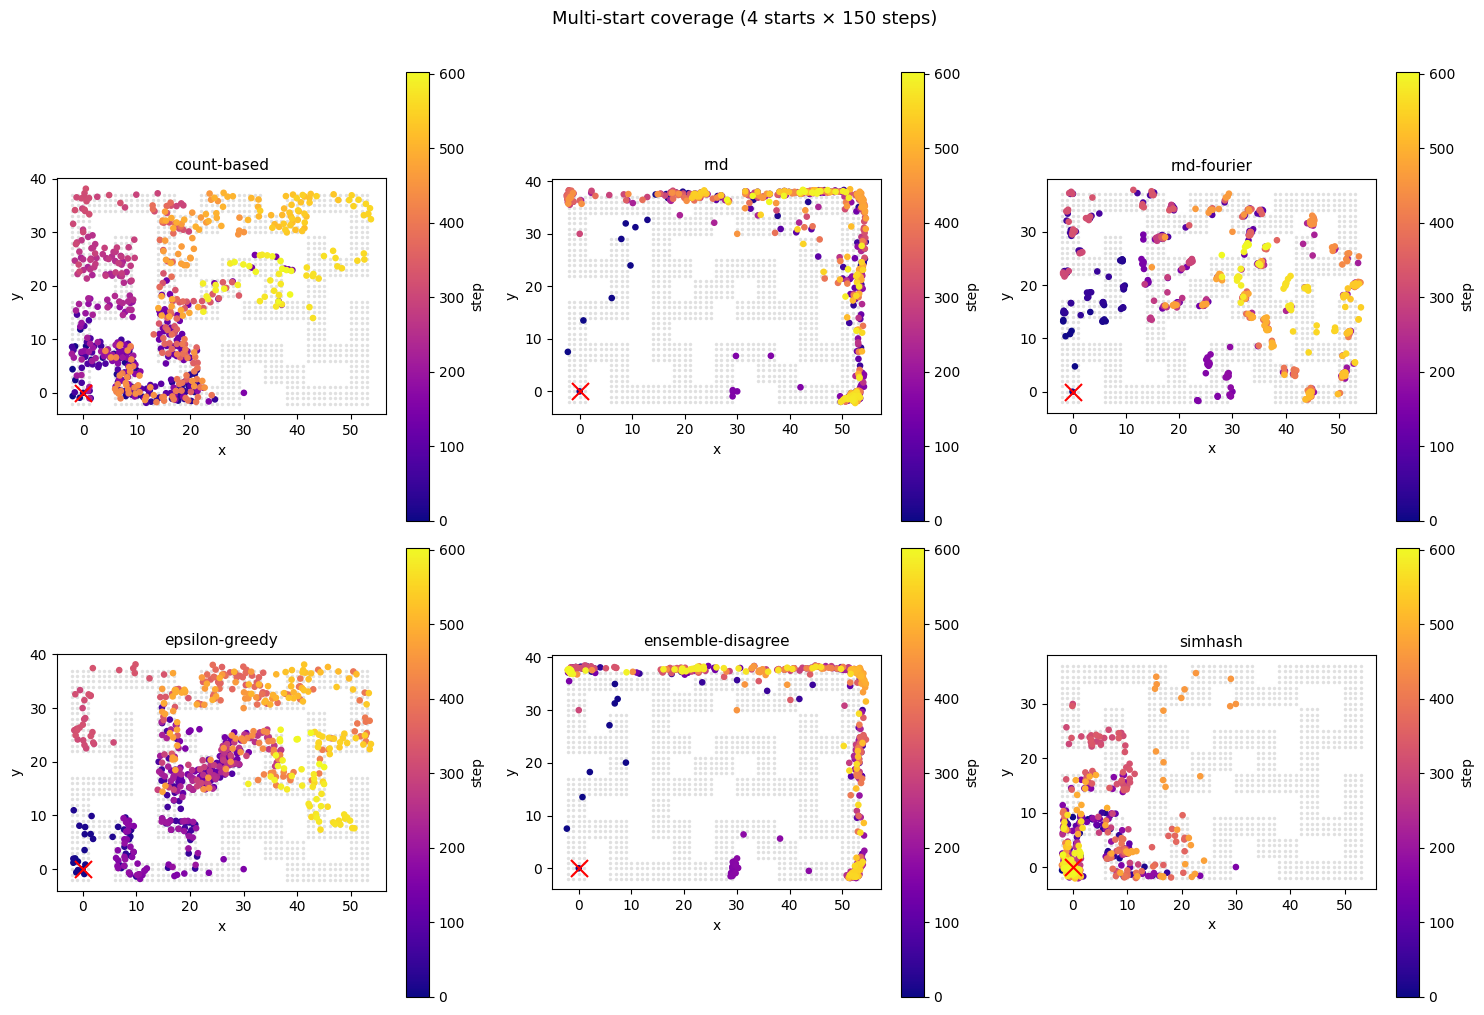

In [22]:
fig = plot_coverage_maps(
    ms_results, all_cell_points, START_POSITIONS[0],
    ncols=3,
    suptitle=f'Multi-start coverage ({len(START_POSITIONS)} starts × {MS_STEPS} steps)',
)
plt.show()

## DQC-Guided Policy Rollouts

Restore the `humanoidmaze-giant` DQC agent and repeat the novelty-scorer experiments, but instead of teleporting to each chosen subgoal the DQC policy executes **25 environment steps** conditioned on that subgoal before resampling.  This measures exploration coverage under an actual low-level controller rather than an oracle.

In [1]:
import json
from agents import agents as agent_registry
from utils.flax_utils import restore_agent
from wrappers.datafuncs_utils import make_env_and_datasets, to_oracle_reps

DQC_PATH = '../../scratch/dqc-reproduce/sd100001s_33415523.0.33415522.1.20260415_020458/'
DQC_CKPT = 1_000_000

with open(f'{DQC_PATH}/flags.json') as f:
    dqc_flags = json.load(f)
dqc_agent_config = dqc_flags['agent']

# placeholder values
dqc_agent_config['actor_p_curgoal'] = 0.5
dqc_agent_config['actor_p_trajgoal'] = 0.5
dqc_agent_config['actor_p_randomgoal'] = 0.0
dqc_agent_config['actor_geom_sample'] = 0.5
dqc_agent_config['subgoal_steps'] = 100
dqc_agent_config['train_goal_proposer'] = False


# DQC was trained on humanoidmaze-giant-navigate-oraclerep-v0:
# observations = 2D xy oracle reps, actions = 21-dim
ACTION_DIM = 21
ORACLE_DIM = 2  # xy

dqc_example_batch = {
    'observations':                np.zeros((1, ORACLE_DIM), dtype=np.float32),
    'actions':                     np.zeros((1, ACTION_DIM), dtype=np.float32),
    'high_value_goals':            np.zeros((1, ORACLE_DIM), dtype=np.float32),
    'high_value_reps':             np.zeros((1, ORACLE_DIM), dtype=np.float32),
    'high_value_next_observations':np.zeros((1, ORACLE_DIM), dtype=np.float32),
    'high_value_action_chunks':    np.zeros((1, dqc_agent_config['backup_horizon'] * ACTION_DIM), dtype=np.float32),
    'high_actor_goals':            np.zeros((1, ORACLE_DIM), dtype=np.float32),
    'low_actor_goals':             np.zeros((1, ORACLE_DIM), dtype=np.float32),
}

dqc_agent = agent_registry['dqc'].create(0, dqc_example_batch, dqc_agent_config)
dqc_agent = restore_agent(dqc_agent, DQC_PATH, DQC_CKPT)
print(f'Restored DQC agent from step {DQC_CKPT}')

env, _, _ = make_env_and_datasets(ENV_NAME, dataset_path=ENV_DATASET_PATH)
print(f'Created env: {env.spec.id}')

/home/jennifer/miniconda3/envs/aorl/lib/python3.10/site-packages/Cython/Distutils/old_build_ext.py:15: DeprecationWarning: dep_util is Deprecated. Use functions from setuptools instead.
  from distutils.dep_util import newer, newer_group
/home/jennifer/miniconda3/envs/aorl/lib/python3.10/site-packages/Cython/Distutils/old_build_ext.py:15: DeprecationWarning: dep_util is Deprecated. Use functions from setuptools instead.
  from distutils.dep_util import newer, newer_group
<frozen importlib._bootstrap>:283: DeprecationWarning: the load_module() method is deprecated and slated for removal in Python 3.12; use exec_module() instead


NameError: name 'np' is not defined

In [24]:
STEPS_TO_SUBGOAL = 25
DQC_NUM_SUBGOALS = NUM_STEPS  # same subgoal budget as oracle rollout


def dqc_rollout(selector, env, dqc_agent, num_subgoals, rng):
    """Select a subgoal with the novelty scorer, execute the DQC policy toward
    it for STEPS_TO_SUBGOAL env steps, then resample.  Records the 2D xy
    oracle rep at every env step."""
    obs_raw, _ = env.reset()
    oracle_rep = np.asarray(to_oracle_reps(obs_raw[None], env_name=ENV_NAME))[0]

    trajectory = [oracle_rep.copy()]
    all_cands  = []
    all_scores = []

    for _ in trange(num_subgoals, leave=False):
        best_subgoal, cands, scores = selector.select(oracle_rep)
        all_cands.append(cands)
        all_scores.append(scores)

        for _ in range(STEPS_TO_SUBGOAL):
            rng, action_rng = jax.random.split(rng)
            action = np.asarray(dqc_agent.sample_actions(
                observations=oracle_rep,
                goals=best_subgoal,
                seed=action_rng,
            ))
            obs_raw, _, terminated, truncated, _ = env.step(action)
            oracle_rep = np.asarray(to_oracle_reps(obs_raw[None], env_name=ENV_NAME))[0]
            trajectory.append(oracle_rep.copy())
            if terminated or truncated:
                obs_raw, _ = env.reset()
                oracle_rep = np.asarray(to_oracle_reps(obs_raw[None], env_name=ENV_NAME))[0]

    return {
        'trajectory': np.stack(trajectory),
        'candidates': all_cands,
        'scores':     all_scores,
    }

In [25]:
dqc_selectors = make_selectors(SEED)
dqc_results   = {}

rng = jax.random.PRNGKey(SEED)
for name, sel in dqc_selectors.items():
    print(f'Rolling out {name} (DQC, {STEPS_TO_SUBGOAL} steps/subgoal) ...')
    rng, rollout_rng = jax.random.split(rng)
    dqc_results[name] = dqc_rollout(sel, env, dqc_agent, DQC_NUM_SUBGOALS, rollout_rng)
    traj  = dqc_results[name]['trajectory']
    cells = {tuple(np.floor(p[:2]).astype(int).tolist()) for p in traj}
    print(f'  → {len(cells)} unique cells ({len(cells)/len(all_cell_points)*100:.1f}% of maze)')

Rolling out count-based (DQC, 25 steps/subgoal) ...


ScopeParamShapeError: Initializer expected to generate shape (91, 1024) but got shape (24, 1024) instead for parameter "kernel" in "/modules_actor_bc/mlp/Dense_0". (https://flax.readthedocs.io/en/latest/api_reference/flax.errors.html#flax.errors.ScopeParamShapeError)

In [ ]:
dqc_start = dqc_results[list(dqc_results.keys())[0]]['trajectory'][0]

fig = plot_coverage_maps(
    dqc_results, all_cell_points, dqc_start,
    ncols=3,
    suptitle=(
        f'DQC Coverage — {DQC_NUM_SUBGOALS} subgoals × {STEPS_TO_SUBGOAL} env steps'
        f'  (horizon={HORIZON:.0f}, N={NUM_CANDIDATES} candidates)'
    ),
)
plt.show()

fig = plot_unique_cells_over_time(dqc_results, bin_size=1.0)
fig.axes[0].set_xlabel('env steps')
fig.axes[0].set_title(f'DQC Exploration Coverage — {STEPS_TO_SUBGOAL} steps/subgoal')
plt.show()

fig = plot_max_novelty_scores(dqc_results)
fig.axes[0].set_title('DQC Max Novelty Score over Time (per subgoal step)')
plt.show()

# Coverage summary bar chart
dqc_names   = list(dqc_results.keys())
dqc_counts  = []
dqc_pcts    = []
for name in dqc_names:
    traj  = dqc_results[name]['trajectory']
    cells = {tuple(np.floor(p[:2]).astype(int).tolist()) for p in traj}
    dqc_counts.append(len(cells))
    dqc_pcts.append(len(cells) / len(all_cell_points) * 100)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].barh(dqc_names, dqc_counts, color='steelblue')
axes[0].set_xlabel('unique cells visited')
axes[0].set_title(f'DQC Coverage after {DQC_NUM_SUBGOALS} subgoals × {STEPS_TO_SUBGOAL} env steps')
for i, v in enumerate(dqc_counts):
    axes[0].text(v + 1, i, str(v), va='center', fontsize=9)

axes[1].barh(dqc_names, dqc_pcts, color='darkorange')
axes[1].set_xlabel('% of maze covered')
axes[1].set_title('% DQC Coverage')
axes[1].set_xlim(0, 100)
for i, v in enumerate(dqc_pcts):
    axes[1].text(v + 0.5, i, f'{v:.1f}%', va='center', fontsize=9)

fig.tight_layout()
plt.show()